In [1]:
# Quick CTR calculation from bin file

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from tqdm import tqdm
import pandas as pd
import statistics as stat

In [6]:
# Reading from photopeak cut data
data_dir = '80long_pcut.bin'
num_cols = 3
num_rows = os.path.getsize(data_dir) // (2*num_cols)
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, num_cols))
print(data[0:5])

# Event counts
eventcounts = np.zeros((128 * 128), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data[i:i+1000000]
    if num_cols == 3:
        ids = np.asarray(chunk[:, [0, 1]], dtype = np.int32)
    else:
        ids = np.asarray(chunk[:, [1, 3]], dtype = np.int32)
    indices = ids[:, 0] * 128 + ids[:, 1]
    np.add.at(eventcounts, indices, 1)
eventcounts = eventcounts.reshape((128, 128))
print(np.sum(eventcounts))

def gaussianbg(x, a, mu, c, bg):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + bg

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

[[  70   33  471]
 [  54   92  888]
 [  37   78  756]
 [  57   76 1309]
 [  86   41 -681]]


Event counts: 100%|██████████| 1/1 [00:00<00:00, 183.92it/s]

156344


In [69]:
tsv_dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/tsvs'
lookup = np.genfromtxt(os.path.join(tsv_dir, 'time_offset_calibrationit10.tsv'), delimiter = '\t')[:,4]
def applytimeoffsets(row):
    #return row[2] - lookup[row[0] + 128] + lookup[row[1]]
    return row[5] - lookup[row[1] + 128] + lookup[row[3]]


In [8]:
thresh = 50
abovethresh = 0
for rown in range(128):
    for coln in range(128):
        if eventcounts[rown, coln] >= thresh:
            abovethresh += 1
abovethresh

263

In [51]:
pairs = []
numabovethreshold = 0
for rown in range(128):
    for coln in range(128):
        if eventcounts[rown, coln] >= thresh:
            numabovethreshold += 1
            pairs.append((rown, coln))
print(numabovethreshold)

bins = np.linspace(-10000, 10000, 250) # Consistent histogram bins
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

fwhms = []
for pair in tqdm(pairs):
    idl, idr = pair[0], pair[1]
    timediffs = np.zeros(eventcounts[idl, idr])
    writehead = 0
    for i in range(0, num_rows, 1000000):
        chunk = data[i:i+1000000]
        if num_cols == 3:
            chunk = chunk[chunk[:,0] == idl]
            chunk = chunk[chunk[:,1] == idr]
            timediffs[writehead:writehead + len(chunk)] = chunk[:,2]
        else:
            chunk = chunk[chunk[:,1] == idl]
            chunk = chunk[chunk[:,3] == idr]
            timediffs[writehead:writehead + len(chunk)] = chunk[:,4]
        writehead += len(chunk)
    #timediffs = timediffs - lookup[idl + 128] + lookup[idr]
    hist = np.histogram(timediffs, bins = bins)[0]
    maxindex = np.where(hist == np.max(hist))[0][0]
    try:
        # Initial fit
        #popt, pcov = curve_fit(gaussian, bincenters[maxindex-10:maxindex+10], hist[maxindex-10:maxindex+10], p0 = [4, bincenters[maxindex], 100])
        popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [10, 0, 500, 10])
        #print(popt)
        #print(np.abs(popt[2] * 2.355))
        fwhms.append(np.abs(popt[2] * 2.355))
    except:
        print(f'failed {pair}')
print(fwhms)
print(np.mean(fwhms))

263


  0%|          | 0/263 [00:00<?, ?it/s]/tmp/ipykernel_1894954/3216337877.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [10, 0, 500, 10])
 42%|████▏     | 111/263 [00:00<00:00, 1104.51it/s]

failed (37, 95)


100%|██████████| 263/263 [00:00<00:00, 1182.13it/s]

[np.float64(855.5451368505579), np.float64(609.6556399304651), np.float64(908.0268133131132), np.float64(624.979731207635), np.float64(781.0556763367371), np.float64(660.2973301411974), np.float64(662.0462461942524), np.float64(858.8161221068783), np.float64(689.002302482648), np.float64(749.6638684864257), np.float64(463.9019638653701), np.float64(1007.3126008496306), np.float64(920.2541397709942), np.float64(698.1555929059725), np.float64(535.3043649048341), np.float64(584.1713241058521), np.float64(561.3952450960663), np.float64(659.0050711142621), np.float64(223.19618903568016), np.float64(8960.234200843164), np.float64(1647.152970831926), np.float64(376.3282502399729), np.float64(510.8890903328132), np.float64(558.638999392527), np.float64(557.3479621934906), np.float64(454.5862170243906), np.float64(741.4681723695736), np.float64(1293.9437548971794), np.float64(612.5757563310979), np.float64(514.3691058789761), np.float64(460.46792525241625), np.float64(1146.1300967098314), np.fl

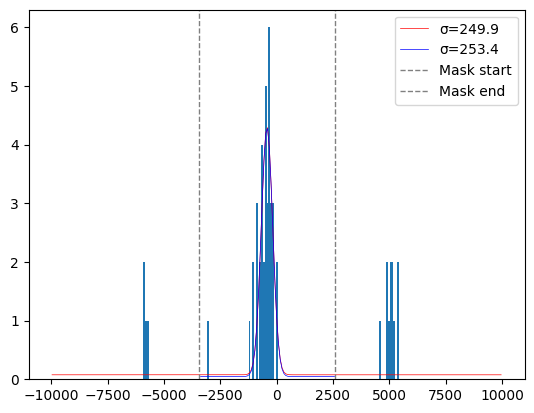

In [53]:
import random

random_int = random.randint(0, len(pairs))
pair = pairs[random_int]
idl, idr = pair[0], pair[1]
timediffs = np.zeros(eventcounts[idl, idr])
writehead = 0
for i in range(0, num_rows, 1000000):
    chunk = data[i:i+1000000]
    if num_cols == 3:
        chunk = chunk[chunk[:,0] == idl]
        chunk = chunk[chunk[:,1] == idr]
        timediffs[writehead:writehead + len(chunk)] = chunk[:,2]
    else:
        chunk = chunk[chunk[:,1] == idl]
        chunk = chunk[chunk[:,3] == idr]
        timediffs[writehead:writehead + len(chunk)] = chunk[:,4]
    writehead += len(chunk)
hist = np.histogram(timediffs, bins = bins)[0]
maxindex = np.where(hist == np.max(hist))[0][0]

# Initial fit
#popt, pcov = curve_fit(gaussian, bincenters[maxindex-10:maxindex+10], hist[maxindex-10:maxindex+10], p0 = [4, bincenters[maxindex], 100])
popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [10, 0, 500, 10])
plt.plot(bincenters, gaussianbg(bincenters, *popt), color = 'red', linewidth = 0.5, label = f'σ={round(popt[2],1)}')
# Refit with better bounds estimate
# Mask data to around 2.5 sigma of initial fit
#r = 2.5* popt[2]
r = 3000
mu = popt[1]
# Convert bincenters to np.array to allow boolean masking
bincenters_np = np.array(bincenters)
mask = (bincenters_np >= (mu - r)) & (bincenters_np <= (mu + r))
masked_bincenters = bincenters_np[mask]
masked_hist = np.array(hist)[mask]
popt, pcov = curve_fit(gaussianbg, masked_bincenters, masked_hist, p0 = [10, 0, 500, 10])
plt.plot(masked_bincenters, gaussianbg(masked_bincenters, *popt), color = 'blue', linewidth = 0.5, label = f'σ={round(popt[2],1)}')
plt.axvline(mu - r, color='gray', linestyle='--', linewidth=1, label='Mask start')
plt.axvline(mu + r, color='gray', linestyle='--', linewidth=1, label='Mask end')

plt.bar(bincenters, hist, width = bins[1] - bins[0])
plt.legend()
plt.show()

[ 22.10384405 619.5625431  155.25047443   0.6992217 ]
[ 1.19627761  9.34363536 10.37800245  0.45519598]


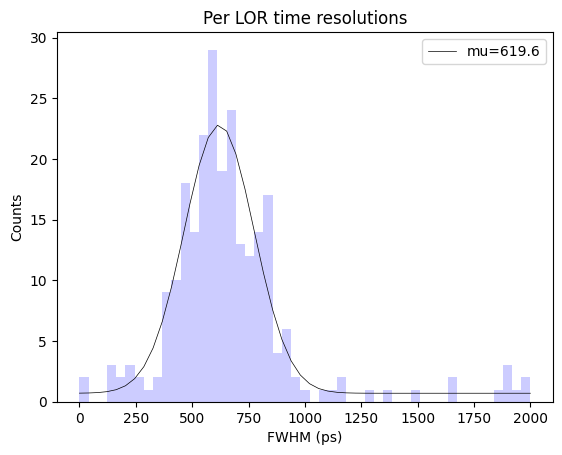

In [56]:
binsa = np.linspace(0, 2000, 50)
bincentersa = [(binsa[n] + binsa[n + 1]) / 2 for n in range(len(binsa) - 1)]


hist = plt.hist(fwhms, bins = binsa, color = 'blue', alpha = 0.2)[0]
popt, pcov = curve_fit(gaussianbg, bincentersa, hist, p0 = [10, 600, 200, 0])
print(popt)
perr = np.sqrt(np.diag(pcov))
print(perr)
plt.plot(binsa, gaussianbg(binsa, *popt), color = 'black', linewidth = 0.5, label = f'mu={round(popt[1],1)}')
plt.title('Per LOR time resolutions')
plt.xlabel('FWHM (ps)')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [76]:
hist1 = hist
popt1 = popt
perr1 = perr

In [66]:
hist2 = hist
popt2 = popt
perr2 = perr


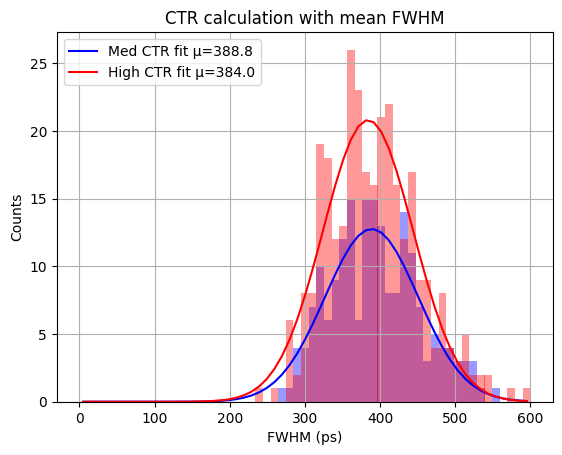

In [79]:
plt.bar(bincentersa, hist1, width = 10.2, color = 'blue', alpha = 0.4)
plt.bar(bincentersa, hist2, width = 10.2, color = 'red', alpha = 0.4)
plt.plot(bincentersa, gaussian(bincentersa, *popt1), color = 'blue', label = f'Med CTR fit μ={round(popt1[1], 1)}')
plt.plot(bincentersa, gaussian(bincentersa, *popt2), color = 'red', label = f'High CTR fit μ={round(popt2[1], 1)}')
plt.grid()
plt.legend()
plt.xlabel('FWHM (ps)')
plt.ylabel('Counts')
plt.title('CTR calculation with mean FWHM')
plt.show()